In [1]:
1

1

In [2]:
#Première partie de nettoyage : 3 heures 

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Charger le fichier CSV dans un DataFrame Pandas
file_path = "D:\M2IFormation\PROJET FINAL\Amazon data\Amazon-Products.csv"
amazon_df = pd.read_csv(file_path)

In [5]:
# Afficher les premières lignes du DataFrame
print(amazon_df.head(20))
# Afficher les dernières lignes du DataFrame
print(amazon_df.tail(20))

    Unnamed: 0                                               name  \
0            0  Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...   
1            1  LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...   
2            2  LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...   
3            3  LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...   
4            4  Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...   
5            5  Voltas 1.4 Ton 3 Star Inverter Split AC(Copper...   
6            6  Lloyd 1.0 Ton 3 Star Inverter Split Ac (5 In 1...   
7            7  Lloyd 1.5 Ton 5 Star Inverter Split Ac (5 In 1...   
8            8  Carrier 1 Ton 3 Star AI Flexicool Inverter Spl...   
9            9  Voltas 1.5 Ton, 5 Star, Inverter Split AC(Copp...   
10          10  Daikin 1 Ton 3 Star Inverter Split AC (Copper,...   
11          11  Daikin 1.5 Ton 5 Star Inverter Split AC (Coppe...   
12          12  Panasonic 1.5 Ton 5 Star Wi-Fi Inverter Smart ...   
13          13  Carrier 1.5 Ton 5 

        Unnamed: 0                                               name  \
551565        1084  GYMBROTHERS Men's Workout Hooded Body Building...   
551566        1085          Indirage Women's Basic Fleece Crop Hoodie   
551567        1086       Adidas Women's Cotton Hooded Neck Sweatshirt   
551568        1087                              Adidas Men's Standard   
551569        1088  Amazon Brand - Symactive Men's Activewear Gym ...   
551570        1089  HeartInk® BTS Bangtan Boys Fan Art Printed Bla...   
551571        1090  ELEG & STILANCE Fitness Workout Shorts Women E...   
551572        1091                Amazon Brand - Symactive Men Shorts   
551573        1092  Prabodham Unisex Regular Fit Plain Cotton Hood...   
551574        1093  Just rider Arm Sleeves UV Protection for Drivi...   
551575        1094       Just Rider Compression Clothing (XXL, Black)   
551576        1095  PANCHTATAVA Yoga Mat Cover with Adjustable Sho...   
551577        1096  Obsessions Reversible Printed Y

In [7]:
# Afficher des informations sur le DataFrame: 
print("\nInformations sur le DataFrame :")
print(amazon_df.info())


Informations sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551585 entries, 0 to 551584
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Unnamed: 0      551585 non-null  int64 
 1   name            551585 non-null  object
 2   main_category   551585 non-null  object
 3   sub_category    551585 non-null  object
 4   image           551585 non-null  object
 5   link            551585 non-null  object
 6   ratings         375791 non-null  object
 7   no_of_ratings   375791 non-null  object
 8   discount_price  490422 non-null  object
 9   actual_price    533772 non-null  object
dtypes: int64(1), object(9)
memory usage: 42.1+ MB
None


In [8]:
# Vérifier les valeurs manquantes dans chaque colonne
missing_values = amazon_df.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values)

Valeurs manquantes par colonne :
 Unnamed: 0             0
name                   0
main_category          0
sub_category           0
image                  0
link                   0
ratings           175794
no_of_ratings     175794
discount_price     61163
actual_price       17813
dtype: int64


In [9]:
# Supprimer les lignes contenant des valeurs manquantes
amazon_df_cleaned = amazon_df.dropna()

# Filtrer les lignes avec des valeurs manquantes dans le DataFrame nettoyé
missing_values_rows_cleaned = amazon_df[amazon_df.isnull().any(axis=1)]

# Afficher les lignes contenant des valeurs manquantes dans le DataFrame nettoyé
print("Lignes contenant des valeurs manquantes après nettoyage :\n", missing_values_rows_cleaned)


Lignes contenant des valeurs manquantes après nettoyage :
         Unnamed: 0                                               name  \
24              24  Lloyd 1.5 Ton 3 Star Fixed Speed Window Ac (Co...   
50              50  Samsung 1 Ton 5 Star Inverter Split AC (Copper...   
57              57  Haier 1.5 Ton 3 Star Frost Self Clean Inverter...   
69              69  Lloyd 2.0 Ton 3 Star Inverter Split Ac (5 In 1...   
73              73  Voltas 1.5 Ton 3 Star, Fixed Speed Window AC (...   
...            ...                                                ...   
551569        1088  Amazon Brand - Symactive Men's Activewear Gym ...   
551574        1093  Just rider Arm Sleeves UV Protection for Drivi...   
551577        1096  Obsessions Reversible Printed Yoga Mat,Anti-Sl...   
551578        1097                              Puma Women Sweatshirt   
551583        1102                                    Puma Men Shorts   

           main_category      sub_category  \
24            appl

In [10]:
# Supprimer les doublons
amazon_df = amazon_df.drop_duplicates()

In [11]:
# Identifier les doublons dans le DataFrame original
duplicate_rows = amazon_df[amazon_df.duplicated()]

# Afficher les lignes identiques (doublons) dans le DataFrame original
print("Lignes doublons supprimées :\n", duplicate_rows)


Lignes doublons supprimées :
 Empty DataFrame
Columns: [Unnamed: 0, name, main_category, sub_category, image, link, ratings, no_of_ratings, discount_price, actual_price]
Index: []


In [12]:
# Remplacer le contenu de chaque case de la colonne "image" par "link" si la case n'est pas vide, sinon par "no link"
amazon_df['image'] = amazon_df['image'].apply(lambda x: 'image' if pd.notna(x) else 'no image')

# Remplacer le contenu de chaque case de la colonne "link" par "link" si la case n'est pas vide, sinon par "no link"
amazon_df['link'] = amazon_df['link'].apply(lambda x: 'link' if pd.notna(x) else 'no link')

# Afficher les premières lignes du DataFrame après modification
print(amazon_df.head())




   Unnamed: 0                                               name  \
0           0  Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...   
1           1  LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...   
2           2  LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...   
3           3  LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...   
4           4  Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...   

  main_category      sub_category  image  link ratings no_of_ratings  \
0    appliances  Air Conditioners  image  link     4.2         2,255   
1    appliances  Air Conditioners  image  link     4.2         2,948   
2    appliances  Air Conditioners  image  link     4.2         1,206   
3    appliances  Air Conditioners  image  link     4.0            69   
4    appliances  Air Conditioners  image  link     4.1           630   

  discount_price actual_price  
0        ₹32,999      ₹58,990  
1        ₹46,490      ₹75,990  
2        ₹34,490      ₹61,990  
3        ₹37,990      ₹68,990 

In [13]:


# Remplacer les valeurs non numériques par NaN dans la colonne 'no_of_ratings'
amazon_df['no_of_ratings'] = pd.to_numeric(amazon_df['no_of_ratings'], errors='coerce')

# Supprimer les lignes avec des valeurs vides ou NaN dans tout le DataFrame
amazon_df.dropna(inplace=True)

# Afficher les premières lignes du DataFrame après modification
print(amazon_df.head())



# Convertir la colonne 'no_of_ratings' en float
amazon_df['no_of_ratings'] = amazon_df['no_of_ratings'].astype(float)

# Afficher les premières lignes du DataFrame pour vérifier les modifications
print(amazon_df.head())
print(amazon_df.tail())


    Unnamed: 0                                               name  \
3            3  LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...   
4            4  Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...   
8            8  Carrier 1 Ton 3 Star AI Flexicool Inverter Spl...   
9            9  Voltas 1.5 Ton, 5 Star, Inverter Split AC(Copp...   
10          10  Daikin 1 Ton 3 Star Inverter Split AC (Copper,...   

   main_category      sub_category  image  link ratings  no_of_ratings  \
3     appliances  Air Conditioners  image  link     4.0           69.0   
4     appliances  Air Conditioners  image  link     4.1          630.0   
8     appliances  Air Conditioners  image  link     4.1          674.0   
9     appliances  Air Conditioners  image  link     4.0          801.0   
10    appliances  Air Conditioners  image  link     4.2          558.0   

   discount_price actual_price  
3         ₹37,990      ₹68,990  
4         ₹34,490      ₹67,790  
8         ₹30,990      ₹58,190  
9       

In [14]:
# Convertir les colonnes "discount_price" et "actual_price" en chaînes de caractères
amazon_df['discount_price'] = amazon_df['discount_price'].astype(str)
amazon_df['actual_price'] = amazon_df['actual_price'].astype(str)

# Supprimer les symboles de devise et les virgules des colonnes "discount_price" et "actual_price" et convertir en float
amazon_df['discount_price'] = amazon_df['discount_price'].str.replace('₹', '').str.replace(',', '').astype(float)
amazon_df['actual_price'] = amazon_df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)


# Afficher les premières lignes du DataFrame pour vérifier les modifications
print(amazon_df.head())
print(amazon_df.tail())




    Unnamed: 0                                               name  \
3            3  LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...   
4            4  Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...   
8            8  Carrier 1 Ton 3 Star AI Flexicool Inverter Spl...   
9            9  Voltas 1.5 Ton, 5 Star, Inverter Split AC(Copp...   
10          10  Daikin 1 Ton 3 Star Inverter Split AC (Copper,...   

   main_category      sub_category  image  link ratings  no_of_ratings  \
3     appliances  Air Conditioners  image  link     4.0           69.0   
4     appliances  Air Conditioners  image  link     4.1          630.0   
8     appliances  Air Conditioners  image  link     4.1          674.0   
9     appliances  Air Conditioners  image  link     4.0          801.0   
10    appliances  Air Conditioners  image  link     4.2          558.0   

    discount_price  actual_price  
3          37990.0       68990.0  
4          34490.0       67790.0  
8          30990.0       58190.0  


In [15]:
# Créer un dictionnaire de DataFrames pour stocker les DataFrames divisés par catégorie
dfs_by_category = {}

# Parcourir les valeurs uniques de la colonne "main_category"
for category in amazon_df['main_category'].unique():
    # Sélectionner les lignes correspondant à la catégorie actuelle
    category_df = amazon_df[amazon_df['main_category'] == category]
    # Stocker le DataFrame de la catégorie dans le dictionnaire
    dfs_by_category[category] = category_df

In [75]:
# Afficher le nombre de catégories
num_categories = len(amazon_df['main_category'].unique())
print("Nombre total de catégories :", num_categories)

Nombre total de catégories : 20


In [21]:
# Afficher les différentes catégories dans un tableau
category_counts = amazon_df['main_category'].value_counts()
print("Nombre de produits par catégorie :")
print(category_counts)

Nombre de produits par catégorie :
main_category
accessories                60804
women's clothing           57596
tv, audio & cameras        36964
men's clothing             36381
men's shoes                24105
appliances                 22693
stores                     19060
home & kitchen             11062
sports & fitness            7538
beauty & health             5491
kids' fashion               5483
car & motorbike             4955
toys & baby products        3629
bags & luggage              3068
industrial supplies         2458
women's shoes               2358
grocery & gourmet foods     2035
pet supplies                1126
music                        700
home, kitchen, pets           12
Name: count, dtype: int64


In [22]:
# Vérifier que chaque ligne correspond à un produit :

# Calculer le nombre de lignes pour chaque catégorie
category_row_counts = amazon_df.groupby('main_category').size()

# Afficher le nombre de lignes pour chaque catégorie
print("Nombre de lignes pour chaque catégorie :")
print(category_row_counts)

Nombre de lignes pour chaque catégorie :
main_category
accessories                60804
appliances                 22693
bags & luggage              3068
beauty & health             5491
car & motorbike             4955
grocery & gourmet foods     2035
home & kitchen             11062
home, kitchen, pets           12
industrial supplies         2458
kids' fashion               5483
men's clothing             36381
men's shoes                24105
music                        700
pet supplies                1126
sports & fitness            7538
stores                     19060
toys & baby products        3629
tv, audio & cameras        36964
women's clothing           57596
women's shoes               2358
dtype: int64


In [23]:
# Afficher les premières lignes de chaque DataFrame par catégorie
for category in category_counts.index:
    print("\n" + "="*30)
    print(f"Categorie: {category}")
    print("="*30)
    print(dfs_by_category[category].head())


Categorie: accessories
       Unnamed: 0                                               name  \
36673           1  Boldfit Shoe Bag for Travel & Storage Travel O...   
36680           8  Boldfit Weight Machine For Luggage Weighing Sc...   
36683          11  Safari Pentagon Medium Trolley Bag, 65 cm Suit...   
36690          18  Boldfit Waist Bag for Men Travel Bag for Men C...   
36699          27  American Tourister Kamiliant Polypropylene Har...   

      main_category    sub_category  image  link ratings  no_of_ratings  \
36673   accessories  Bags & Luggage  image  link     4.5          453.0   
36680   accessories  Bags & Luggage  image  link     4.2          366.0   
36683   accessories  Bags & Luggage  image  link     4.3          875.0   
36690   accessories  Bags & Luggage  image  link     4.7          376.0   
36699   accessories  Bags & Luggage  image  link     4.0          233.0   

       discount_price  actual_price  
36673           199.0         599.0  
36680           

In [ ]:
  print(dfs_by_category[category].tail())

In [ ]:
2. 

In [ ]:
# Deuxième partie de statistiques descriptives : 1 heure 

In [24]:
# Analyses des prix: 
average_price = amazon_df['actual_price'].mean()
print("Prix moyen des produits :", average_price, "₹")

Prix moyen des produits : 35530.5084727073 ₹


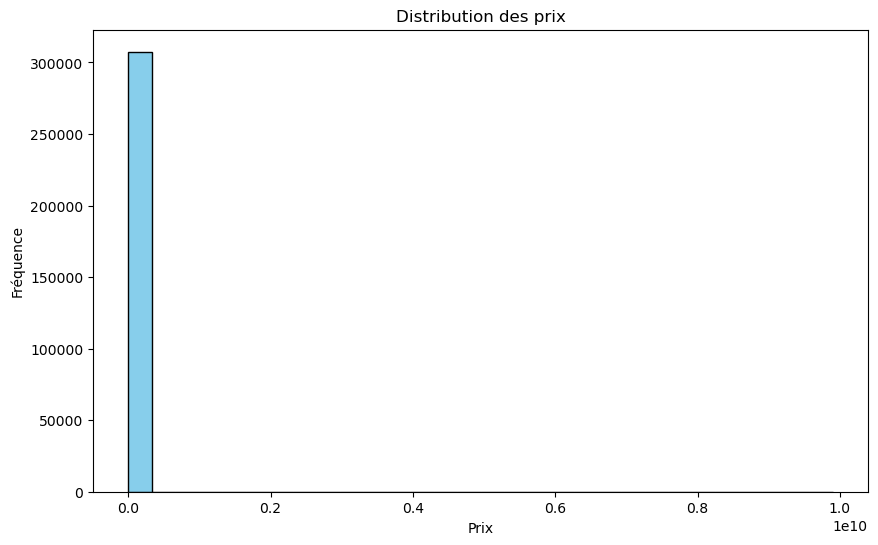

In [25]:
# a refaire
#Visualisation de la distribution des prix :
plt.figure(figsize=(10, 6))
plt.hist(amazon_df['actual_price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution des prix')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

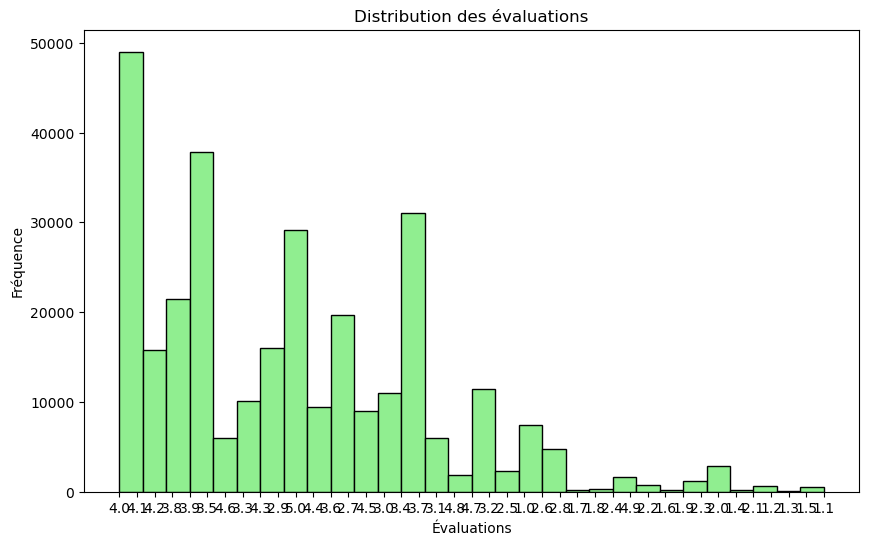

In [26]:
# Visualisation de la distribution des évaluations
plt.figure(figsize=(10, 6))
plt.hist(amazon_df['ratings'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution des évaluations')
plt.xlabel('Évaluations')
plt.ylabel('Fréquence')
plt.show()

In [ ]:
# Analyse par catégorie

In [27]:
# Comparaison des prix moyens par catégorie :
average_prices_by_category = amazon_df.groupby('main_category')['actual_price'].mean()
print(" Prix moyen par catégorie : ", average_prices_by_category)

 Prix moyen par catégorie :  main_category
accessories                  3079.494511
appliances                   7425.585245
bags & luggage               3090.476829
beauty & health              1016.705536
car & motorbike              1753.698795
grocery & gourmet foods       637.058354
home & kitchen             896754.600388
home, kitchen, pets          4458.250000
industrial supplies          3030.315769
kids' fashion                1532.026496
men's clothing               1676.741909
men's shoes                  3359.963206
music                        6102.591043
pet supplies                 1131.436945
sports & fitness            10956.199439
stores                       2601.105111
toys & baby products         1346.289022
tv, audio & cameras          5862.618141
women's clothing             1807.104760
women's shoes                1818.079517
Name: actual_price, dtype: float64


In [ ]:
# Analyse du nombre d'évaluations :

In [29]:
# Calcul du nombre total d'évaluations :
total_ratings = amazon_df['no_of_ratings'].sum()
print("Nombre total d'évaluations :", total_ratings)

Nombre total d'évaluations : 27277027.0


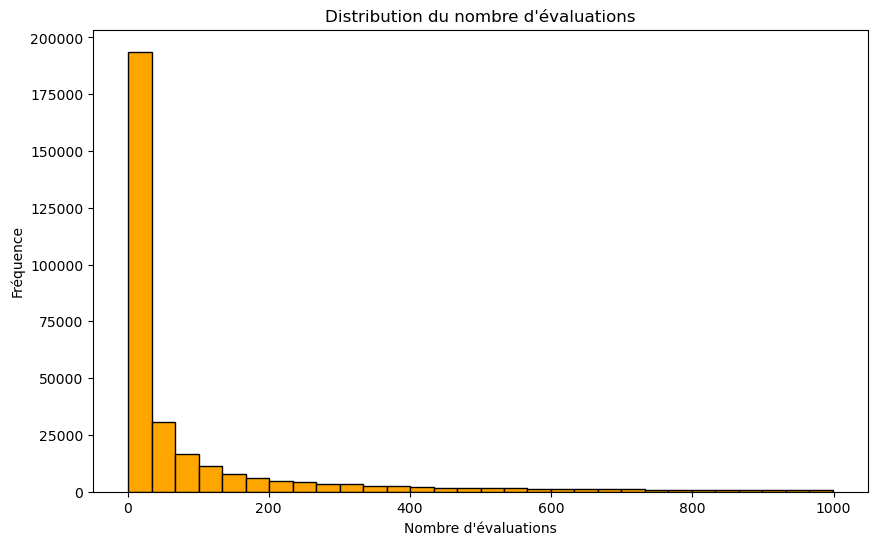

In [30]:
# Visualisation de la distribution du nombre d'évaluations :
plt.figure(figsize=(10, 6))
plt.hist(amazon_df['no_of_ratings'], bins=30, color='orange', edgecolor='black')
plt.title('Distribution du nombre d\'évaluations')
plt.xlabel('Nombre d\'évaluations')
plt.ylabel('Fréquence')
plt.show()

In [ ]:
# TOP 10 des produits par prix : 

In [31]:
top_10_price = amazon_df.nlargest(10, 'actual_price')
print("Top 10 des produits par prix :\n", top_10_price)
plt.show()

Top 10 des produits par prix :
         Unnamed: 0                                               name  \
194625         853  Marutivilla Insect Killer, Mosquito Killer Lig...   
402750         351  Clovia Women's Activewear Ankle Length Printed...   
498818         584  Samsung 214 cm (85 inches) 8K Ultra HD Smart N...   
195762         886  Sri Jagdamba Pearls 10 Gm 24kt (999) Yellow Go...   
498607         373  Sony Bravia 195 cm (77 inches) XR Series 4K Ul...   
498811         577  Samsung 189 cm (75 inches) 4K Ultra HD Smart N...   
498614         380  Sony Bravia 164 cm (65 inches) XR Series 4K Ul...   
498793         559  Samsung 189 cm (75 inches) The Frame Series 4K...   
498823         589  LG 190.5 cm (75 inches) 75SK8000PTA 4K Super U...   
73356         3396  Canon EOS 5D Mark IV 30.4 MP Digital SLR Camer...   

              main_category              sub_category  image  link ratings  \
194625       home & kitchen         Garden & Outdoors  image  link     2.0   
402750  

D:\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


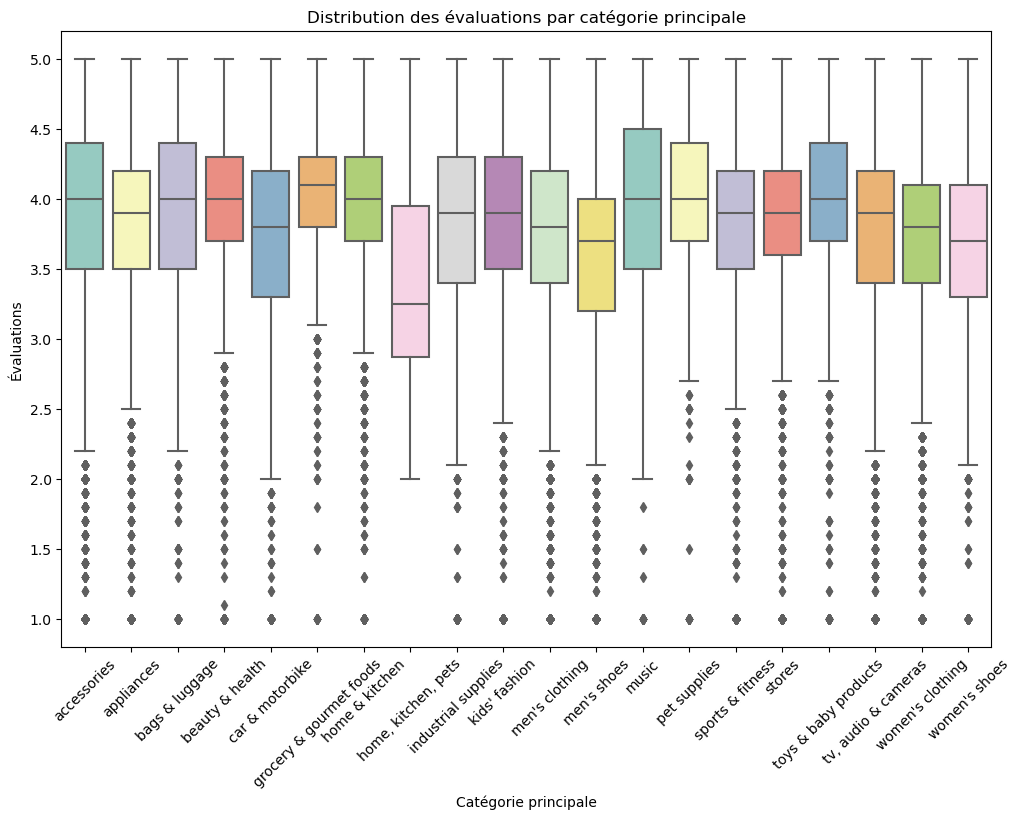

In [39]:
# Assurez-vous que la colonne 'ratings' est de type numérique
amazon_df['ratings'] = pd.to_numeric(amazon_df['ratings'], errors='coerce')

# Assurez-vous que la colonne 'main_category' est de type catégoriel
amazon_df['main_category'] = amazon_df['main_category'].astype('category')

# Visualisation de la distribution des évaluations par catégorie principale
plt.figure(figsize=(12, 8))
sns.boxplot(x='main_category', y='ratings', data=amazon_df, palette='Set3')
plt.title('Distribution des évaluations par catégorie principale')
plt.xlabel('Catégorie principale')
plt.ylabel('Évaluations')
plt.xticks(rotation=45)
plt.show()

In [40]:
# Convertir la colonne 'ratings' en type numérique (float)
amazon_df['ratings'] = pd.to_numeric(amazon_df['ratings'], errors='coerce')

# Supprimer les lignes avec des valeurs NaN dans la colonne 'ratings'
amazon_df.dropna(subset=['ratings'], inplace=True)

# Maintenant, vous pouvez utiliser nlargest pour obtenir le top 10 des produits par évaluations
top_10_ratings = amazon_df.nlargest(10, 'ratings')
print("Top 10 des produits par évaluations :\n", top_10_ratings)

Top 10 des produits par évaluations :
      Unnamed: 0                                               name  \
58           58  Hitachi Split Ac - 1.5 Ton Kiyora 5200Fx I Fre...   
89           89  Panasonic 2 Ton 5 Star Wi-Fi Inverter Smart Sp...   
97           97  Panasonic 1.5 Ton 3 Star Hot and Cold Wi-Fi In...   
113         113  Voltas 2 Ton 5 Star Inverter Split AC (Copper ...   
117         117  Voltas 1 Ton 5 Star, Inverter Split AC(Copper,...   
136         136  ONIDA 1.5 Ton 3 Star Inverter Split AC (Copper...   
150         150  AC Stand/Heavy Duty Air Conditioner Outdoor Un...   
159         159  Carrier 1.5 Ton 5 Star Smart AI Flexicool Hybr...   
171         171  Daikin 1.8 Ton 5 Star Inverter Split AC (Coppe...   
191         191  O-General 1 Ton 5 Star EFFICIENT & TROPICAL In...   

    main_category      sub_category  image  link  ratings  no_of_ratings  \
58     appliances  Air Conditioners  image  link      5.0            1.0   
89     appliances  Air Conditioners  i

C:\Users\booby\AppData\Local\Temp\ipykernel_4824\1695125113.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



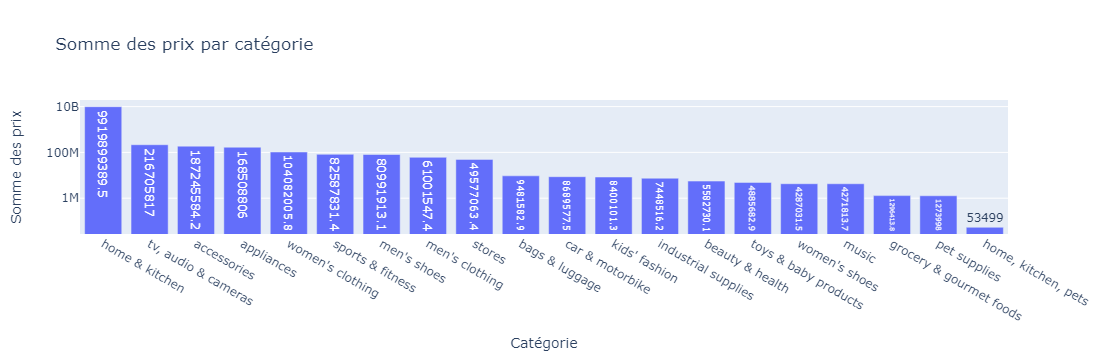

In [62]:
# calculer la somme des prix pour chaque catégorie
subcategory_total_prices = amazon_df.groupby('main_category')['actual_price'].sum()
 
 
# Trier les catégories par somme des prix (descending order)
subcategory_total_prices_sorted = subcategory_total_prices.sort_values(ascending=False)
 
# Créer le graphique à barres avec Plotly Express
fig = px.bar(x=subcategory_total_prices_sorted.index, y=subcategory_total_prices_sorted.values, 
             labels={'x': 'Catégorie', 'y': 'Somme des prix'}, 
             title="Somme des prix par catégorie",
             text=subcategory_total_prices_sorted.values.round(1))  # Ajouter le texte avec les valeurs arrondies à 2 décimales
 
# Mettre à jour l'axe y pour afficher une échelle logarithmique
fig.update_yaxes(type='log')
 
# Afficher le graphique
fig.show()

          Unnamed: 0        ratings  no_of_ratings  discount_price  \
count  307518.000000  307518.000000  307518.000000    3.075180e+05   
mean     6398.461027       3.791658      88.700587    1.684961e+03   
std      5421.990890       0.777880     171.591203    6.375986e+03   
min         0.000000       1.000000       1.000000    8.000000e+00   
25%      1403.000000       3.500000       4.000000    3.590000e+02   
50%      5192.000000       3.900000      15.000000    5.990000e+02   
75%     10026.000000       4.200000      78.000000    1.189000e+03   
max     19199.000000       5.000000     999.000000    1.249990e+06   

       actual_price  
count  3.075180e+05  
mean   3.553051e+04  
std    1.785287e+07  
min    1.000000e+01  
25%    9.000000e+02  
50%    1.499000e+03  
75%    2.699000e+03  
max    9.900000e+09  


D:\Anaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



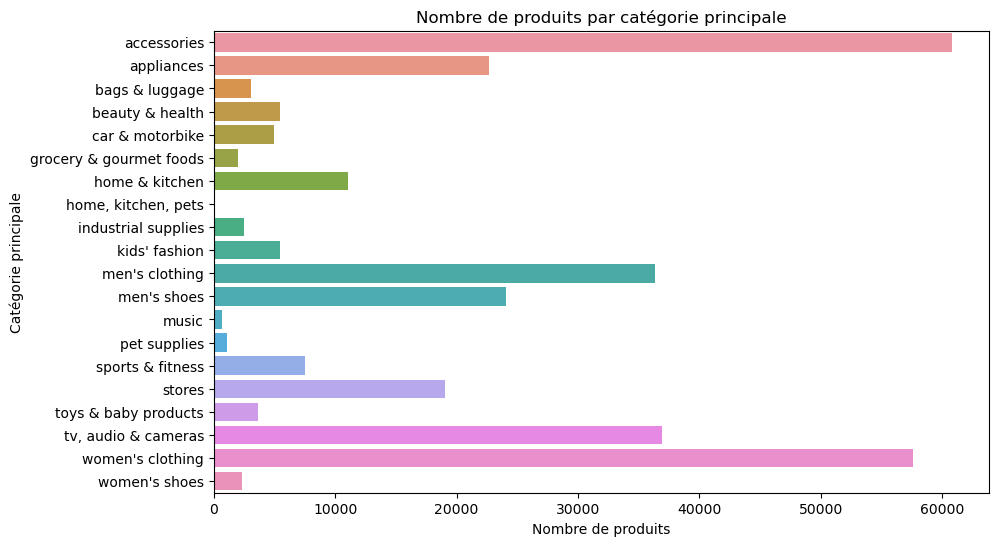

ValueError: could not convert string to float: 'appliances'

In [73]:
# Statistiques descriptives
print(amazon_df.describe())

# Diagramme à barres des catégories principales
plt.figure(figsize=(10, 6))
sns.countplot(data=amazon_df, y='main_category')
plt.title('Nombre de produits par catégorie principale')
plt.xlabel('Nombre de produits')
plt.ylabel('Catégorie principale')
plt.show()

# Corrélation entre les variables numériques
correlation_matrix = amazon_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélation entre les variables numériques')
plt.show()

Statistiques descriptives :
           Unnamed: 0        ratings  no_of_ratings  discount_price  \
count  307518.000000  307518.000000  307518.000000    3.075180e+05   
mean     6398.461027       3.791658      88.700587    1.684961e+03   
std      5421.990890       0.777880     171.591203    6.375986e+03   
min         0.000000       1.000000       1.000000    8.000000e+00   
25%      1403.000000       3.500000       4.000000    3.590000e+02   
50%      5192.000000       3.900000      15.000000    5.990000e+02   
75%     10026.000000       4.200000      78.000000    1.189000e+03   
max     19199.000000       5.000000     999.000000    1.249990e+06   

       actual_price  
count  3.075180e+05  
mean   3.553051e+04  
std    1.785287e+07  
min    1.000000e+01  
25%    9.000000e+02  
50%    1.499000e+03  
75%    2.699000e+03  
max    9.900000e+09  


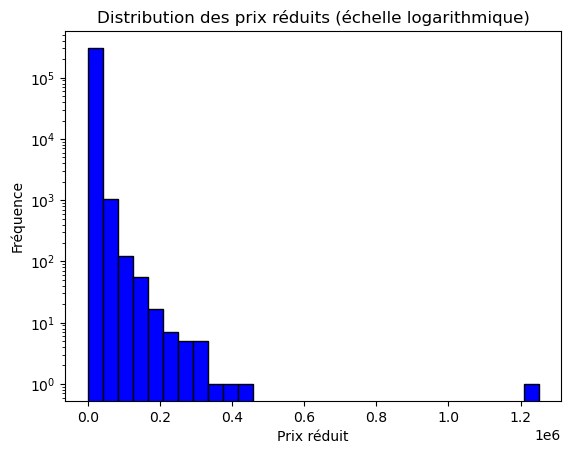

In [68]:
import matplotlib.pyplot as plt

# Afficher les statistiques descriptives
print("Statistiques descriptives :\n", amazon_df.describe())

# Visualiser les données
# Par exemple, histogramme des prix réduits
plt.hist(amazon_df['discount_price'], bins=30, color='blue', edgecolor='black')
plt.xlabel('Prix réduit')
plt.ylabel('Fréquence')
plt.title('Distribution des prix réduits (échelle logarithmique)')
plt.yscale('log')  # Mettre l'échelle y en logarithmique
plt.show()


In [87]:
# Afficher les statistiques descriptives
print("Statistiques descriptives :\n", amazon_df.describe())

Statistiques descriptives :
           Unnamed: 0        ratings  no_of_ratings  discount_price  \
count  307518.000000  307518.000000  307518.000000    3.075180e+05   
mean     6398.461027       3.791658      88.700587    1.684961e+03   
std      5421.990890       0.777880     171.591203    6.375986e+03   
min         0.000000       1.000000       1.000000    8.000000e+00   
25%      1403.000000       3.500000       4.000000    3.590000e+02   
50%      5192.000000       3.900000      15.000000    5.990000e+02   
75%     10026.000000       4.200000      78.000000    1.189000e+03   
max     19199.000000       5.000000     999.000000    1.249990e+06   

       actual_price  
count  3.075180e+05  
mean   3.553051e+04  
std    1.785287e+07  
min    1.000000e+01  
25%    9.000000e+02  
50%    1.499000e+03  
75%    2.699000e+03  
max    9.900000e+09  


D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



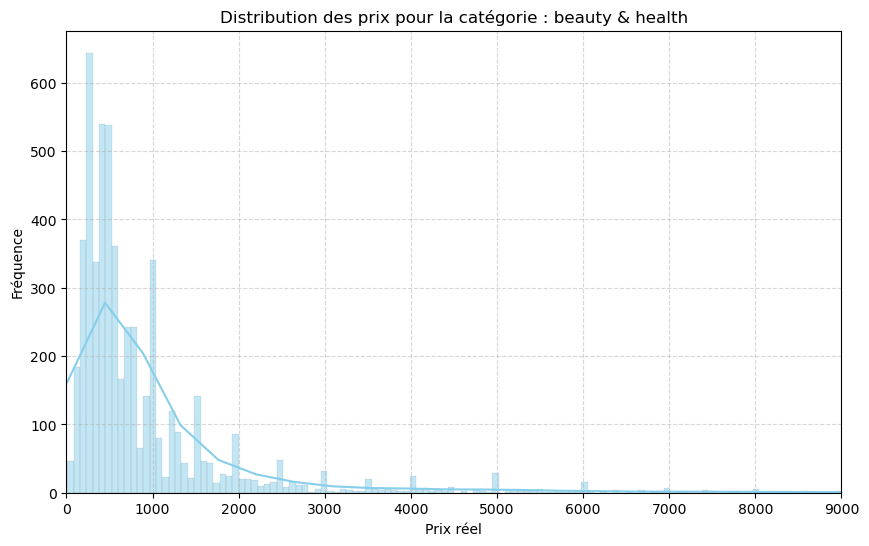

In [88]:
# Sélectionner uniquement les données de la catégorie "beauty & health"
category_beauty_health = amazon_df[amazon_df['main_category'] == 'beauty & health']

# Afficher un histogramme des prix réels avec une limite supérieure de 20000 sur l'axe x
plt.figure(figsize=(10, 6))
sns.histplot(data=category_beauty_health, x='actual_price', kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution des prix pour la catégorie : beauty & health')
plt.xlabel('Prix réel')
plt.ylabel('Fréquence')
plt.xlim(0, 9000)  # Limiter l'axe x à un montant maximum de 20000
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [90]:
# Obtenir la liste des catégories uniques
categories_uniques = amazon_df['main_category'].unique()

# Afficher la liste des catégories
print("Liste des catégories :")
for category in categories_uniques:
    print(category)


Liste des catégories :
appliances
car & motorbike
tv, audio & cameras
sports & fitness
grocery & gourmet foods
home & kitchen
pet supplies
stores
toys & baby products
kids' fashion
bags & luggage
accessories
women's shoes
beauty & health
men's shoes
women's clothing
industrial supplies
men's clothing
music
home, kitchen, pets


In [91]:
#Analyse des prix acutel et prix réduit pour les catégories suivantes : 

C:\Users\booby\AppData\Local\Temp\ipykernel_4824\3187685323.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



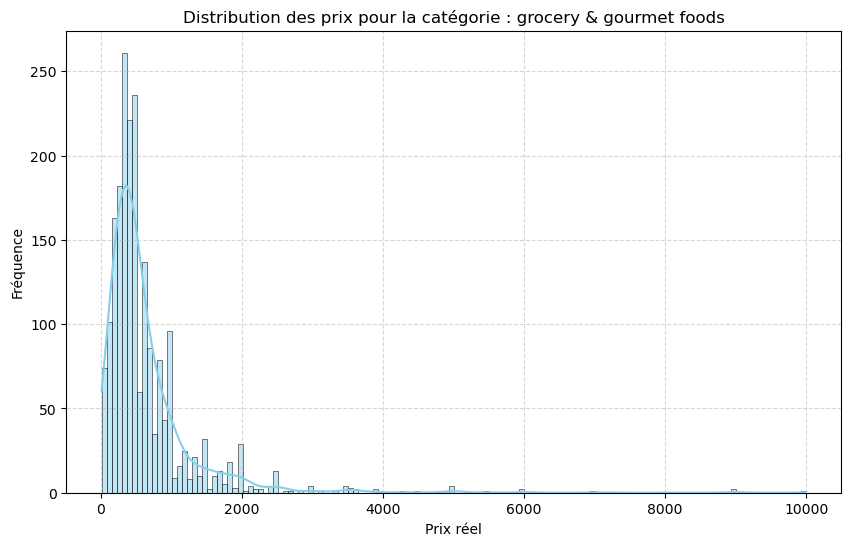

In [96]:
# Sélectionner uniquement les données de la catégorie "car & motorbike"
category_data = amazon_df[amazon_df['main_category'] == 'grocery & gourmet foods']
 
# Convertir la colonne 'actual_price' en chaîne
category_data['actual_price'] = category_data['actual_price'].astype(str)
 
# Filtrer les données pour exclure les valeurs non numériques de la colonne 'actual_price'
category_data_numeric_price = category_data[category_data['actual_price'].str.replace('.', '').str.isnumeric()]
 
# Convertir les valeurs restantes en float
category_data_numeric_price['actual_price'] = category_data_numeric_price['actual_price'].astype(float)
 
# Afficher un histogramme des prix réels 
plt.figure(figsize=(10, 6))
sns.histplot(data=category_data_numeric_price, x='actual_price', kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution des prix pour la catégorie : grocery & gourmet foods')
plt.xlabel('Prix réel')
plt.ylabel('Fréquence')
plt.grid(True, linestyle='--', alpha=0.5)
 
plt.show()